# CE322 Pattern Recognition — TikTok Project
## Notebook 5: Evaluation Summary & Key Findings

This notebook consolidates all results, produces the final comparison tables, and summarizes the key insights from both supervised and unsupervised analyses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

print("=== CE322 TikTok Pattern Recognition — Final Results ===")
print(f"Dataset: 55,160 videos | 214 Turkish influencers | 10 categories")

=== CE322 TikTok Pattern Recognition — Final Results ===
Dataset: 55,160 videos | 214 Turkish influencers | 10 categories


## 5.1 Supervised Learning — Final Comparison

In [2]:
cv_df   = pd.read_csv('../data/cv_results.csv', index_col=0)
test_df = pd.read_csv('../data/test_results.csv', index_col=0)

summary = pd.concat([
    cv_df[['CV Accuracy (mean)', 'CV F1-macro (mean)']],
    test_df[['Test Accuracy', 'Test F1-macro']]
], axis=1).round(4)

summary = summary.sort_values('Test F1-macro', ascending=False)
summary.columns = ['CV Accuracy', 'CV F1-macro', 'Test Accuracy', 'Test F1-macro']
print("=== Classification Model Comparison ===")
print(summary.to_string())

# Best model
best = summary['Test F1-macro'].idxmax()
print(f"\n>>> Best model: {best} (F1-macro = {summary.loc[best, 'Test F1-macro']:.4f})")

=== Classification Model Comparison ===
                     CV Accuracy  CV F1-macro  Test Accuracy  Test F1-macro
Decision Tree             0.9830       0.9829         0.9850         0.9850
SVM (RBF)                 0.9575       0.9573         0.9598         0.9596
Logistic Regression       0.9412       0.9409         0.9468         0.9465
K-NN (k=7)                0.8465       0.8463         0.8543         0.8540
Naive Bayes               0.6517       0.6400         0.6475         0.6340

>>> Best model: Decision Tree (F1-macro = 0.9850)


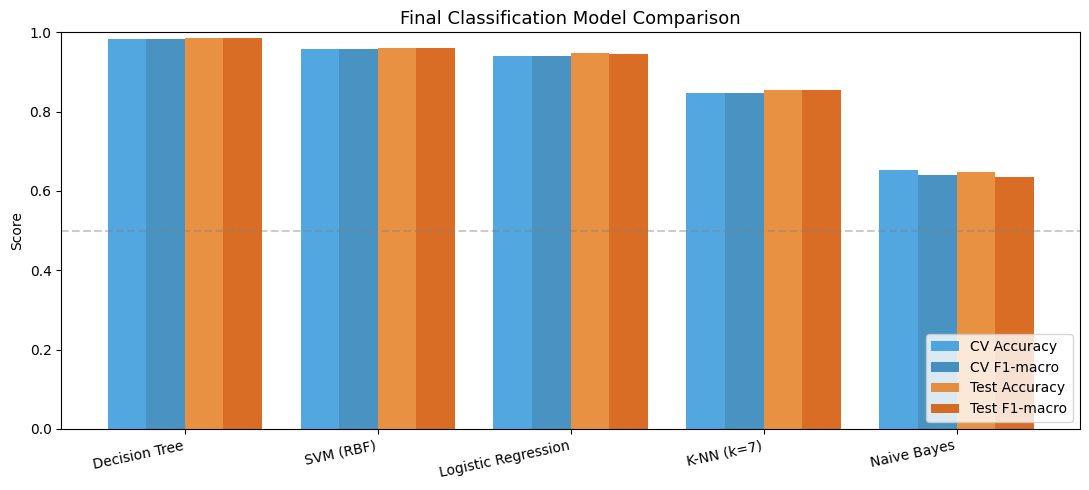

In [3]:
# Final comparison bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary))
w = 0.2
ax.bar(x - 1.5*w, summary['CV Accuracy'],   w, label='CV Accuracy',   color='#3498db', alpha=0.85)
ax.bar(x - 0.5*w, summary['CV F1-macro'],   w, label='CV F1-macro',   color='#2980b9', alpha=0.85)
ax.bar(x + 0.5*w, summary['Test Accuracy'], w, label='Test Accuracy', color='#e67e22', alpha=0.85)
ax.bar(x + 1.5*w, summary['Test F1-macro'], w, label='Test F1-macro', color='#d35400', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=12, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Final Classification Model Comparison', fontsize=13)
ax.legend(loc='lower right')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../data/final_model_comparison.png', dpi=150)
plt.show()

## 5.2 Unsupervised Learning — Cluster Summary

In [4]:
cluster_profile = pd.read_csv('../data/cluster_profiles.csv', index_col=0)
influencer_df   = pd.read_csv('../data/influencer_clusters.csv')

print("=== Video-Level K-Means Cluster Profiles ===")
print(cluster_profile.to_string())

print("\n=== Influencer Tier Distribution ===")
print(influencer_df.groupby('tier')[['avg_play_count', 'avg_engagement', 'video_count']].mean().round(2))

=== Video-Level K-Means Cluster Profiles ===
                engagement_rate  like_to_play  share_to_play  comment_to_play  duration_seconds  hashtag_count  posting_hour  time_gap_days
kmeans_cluster                                                                                                                             
0                        0.0238        0.0240         0.0011           0.0619           48.6164         4.7242       14.0536       473.6273
1                        0.0380        0.0441         0.0025           0.0004           43.2774         2.6510       14.9970       582.3542

=== Influencer Tier Distribution ===
      avg_play_count  avg_engagement  video_count
tier                                             
0         1826658.91            0.05       231.00
1          251625.03            0.03       320.09
2          119224.06            0.02       166.84


## 5.3 Temporal Engagement Analysis

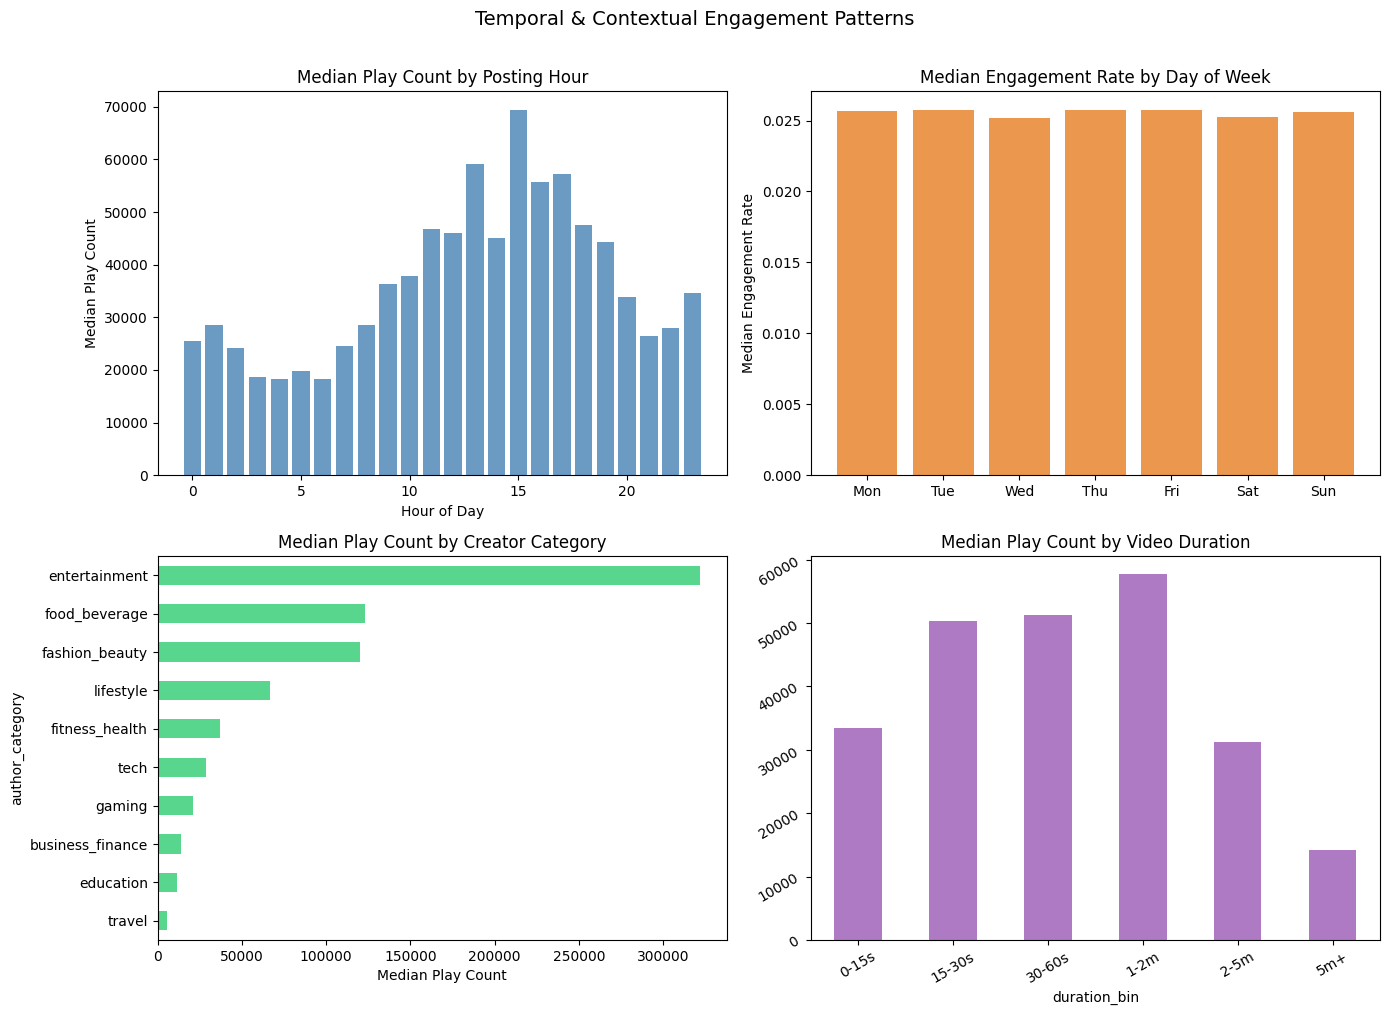

In [5]:
df = pd.read_csv('../data/tiktok_features.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Posting hour vs avg play_count
hour_perf = df.groupby('posting_hour')['play_count'].median()
axes[0,0].bar(hour_perf.index, hour_perf.values, color='steelblue', alpha=0.8)
axes[0,0].set_title('Median Play Count by Posting Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Median Play Count')

# Day of week vs engagement
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_perf = df.groupby('day_of_week')['engagement_rate'].median()
axes[0,1].bar(dow_labels, dow_perf.values, color='#e67e22', alpha=0.8)
axes[0,1].set_title('Median Engagement Rate by Day of Week')
axes[0,1].set_ylabel('Median Engagement Rate')

# Category vs median play count
cat_perf = df.groupby('author_category')['play_count'].median().sort_values(ascending=True)
cat_perf.plot(kind='barh', ax=axes[1,0], color='#2ecc71', alpha=0.8)
axes[1,0].set_title('Median Play Count by Creator Category')
axes[1,0].set_xlabel('Median Play Count')

# Duration vs play count (binned)
df['duration_bin'] = pd.cut(df['duration_seconds'], bins=[0,15,30,60,120,300,1000],
                             labels=['0-15s','15-30s','30-60s','1-2m','2-5m','5m+'])
dur_perf = df.groupby('duration_bin')['play_count'].median()
dur_perf.plot(kind='bar', ax=axes[1,1], color='#9b59b6', alpha=0.8)
axes[1,1].set_title('Median Play Count by Video Duration')
axes[1,1].tick_params(rotation=30)

plt.suptitle('Temporal & Contextual Engagement Patterns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.5 Export All Results

In [9]:
import os
result_files = [
    '../data/cv_results.csv',
    '../data/test_results.csv',
    '../data/cluster_profiles.csv',
    '../data/influencer_clusters.csv',
]
print("=== Generated Result Files ===")
for f in result_files:
    if os.path.exists(f):
        df_tmp = pd.read_csv(f)
        print(f"  {f} — {df_tmp.shape}")

print("\n=== Generated Figures ===")
for f in os.listdir('../data/'):
    if f.endswith('.png'):
        print(f"  {f}")

=== Generated Result Files ===
  ../data/cv_results.csv — (5, 5)
  ../data/test_results.csv — (5, 3)
  ../data/cluster_profiles.csv — (2, 9)
  ../data/influencer_clusters.csv — (214, 12)

=== Generated Figures ===
  elbow_silhouette.png
  final_model_comparison.png
  cluster_profiles_heatmap.png
  temporal_analysis.png
  playcount_dist.png
  dendrogram.png
  pca_clusters.png
  feature_importance.png
  correlation_heatmap.png
  confusion_matrices.png
  influencer_clusters.png
  engagement_dist.png
  model_comparison.png
  label_distribution.png
